In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, feature
from scipy.ndimage import gaussian_filter
from sklearn.mixture import GaussianMixture

In [3]:
img = io.imread('denoised.png', as_gray=True)
img = img.astype(np.float32)
img_smooth = gaussian_filter(img, sigma=1)   #do if needed

In [5]:
#Peak detection
coordinates = feature.peak_local_max(
    img_smooth,
    min_distance=5,
    threshold_abs=np.mean(img_smooth)
)

In [7]:
# Feature Extraction
features = []
positions = []

window = 5

for (y, x) in coordinates:
    y_min = max(0, y - window)
    y_max = min(img.shape[0], y + window)
    x_min = max(0, x - window)
    x_max = min(img.shape[1], x + window)

    patch = img[y_min:y_max, x_min:x_max]

    # Background subtraction
    bg = np.median(patch)
    patch = patch - bg
    patch[patch < 0] = 0

    intensity = np.sum(patch)

    features.append([intensity])
    positions.append((x, y))

features = np.array(features)

In [9]:
#BIC Criteria
bic_scores = []
models = []
K_range = range(1, 6)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(features)
    bic_scores.append(gmm.bic(features))
    models.append(gmm)

# Best model
best_k = K_range[np.argmin(bic_scores)]
best_gmm = models[np.argmin(bic_scores)]

print(f"Optimal number of components (K): {best_k}")

Optimal number of components (K): 1


In [11]:
labels = best_gmm.predict(features)
probs = best_gmm.predict_proba(features)

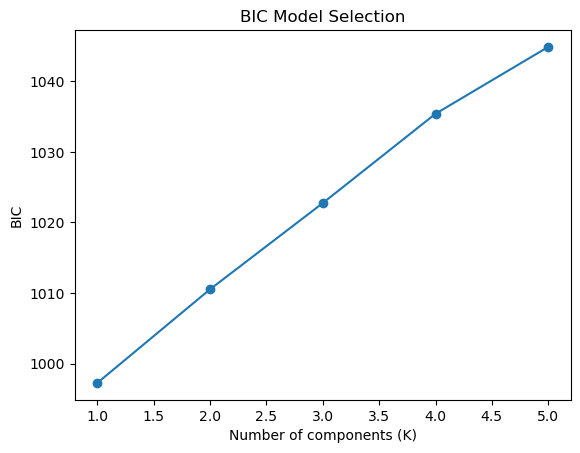

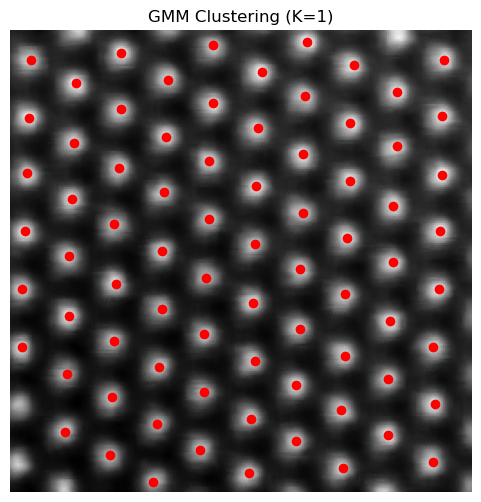

Means:
 [[1034.5]]
Weights:
 [1.]
Covariances:
 [[[26117.27631679]]]


In [13]:
#Plots
# ---------------------------
plt.figure()
plt.plot(K_range, bic_scores, marker='o')
plt.xlabel("Number of components (K)")
plt.ylabel("BIC")
plt.title("BIC Model Selection")
plt.show()


plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')

colors = ['r', 'b', 'g', 'y', 'c']

for (x, y), label in zip(positions, labels):
    plt.plot(x, y, 'o', color=colors[label % len(colors)])

plt.title(f"GMM Clustering (K={best_k})")
plt.axis('off')
plt.show()
print("Means:\n", best_gmm.means_)
print("Weights:\n", best_gmm.weights_)
print("Covariances:\n", best_gmm.covariances_)

In [27]:
import os
import numpy as np
import cv2

# Force working directory to notebook location
os.chdir("/Users/akshitdhillon/Documents/Work/N2V/Codes")

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Not found: {path}")
    return img.astype(np.float32)

noisy = io.imread('test.png', as_gray=True)
clean = io.imread('denoised.png', as_gray=True)
 

print("Loaded successfully!")

Loaded successfully!
